# Understanding variation in lifespans of notable people using the BHHT data

The [BHHT](https://medialab.github.io/bhht-datascape) (Brief History of Human Time) project provides a dataset about "notable people" based mainly on wikipedia biography articles.

The analyses below focus on lifespans of the people in the BHHT dataset, aiming to understand how lifespans vary based on factors including era of birth, the geographic region where the person lived, and the person's sex.

This analysis uses survival analysis methods, allowing us to use information from still-living people.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from scipy.stats.distributions import chi2

Change the path below as needed to point to the directory containing the data file.

In [2]:
pa = Path(".")

Load the dataset.  Use the latin-1 encoding since there is some non-UTF data in the file.  Add "nrows=####" when developing to reduce the run time, but use as much data as practical to get final results.

In [3]:
nrows = 500000
df = pd.read_csv(pa / Path("cross-verified-database.csv.gz"), encoding="latin-1", nrows=nrows)

Create a lifespan variable (years of life).  It will be missing for people who are currently living.

In [4]:
df["lifespan"] = df["death"] - df["birth"]

Most of the death dates correspond to censoring, meaning that people are still alive at the time that the dataset was assembled.  But in some cases, the death dates are missing for people who have certainly died (e.g. people born hundreds of years ago).  To handle this, we exclude all people who have a missing death date and were born before 1900.

In [5]:
dx = df.query("(not death.isna()) or (death.isna() and birth >= 1900)")
dx.shape

,wikidata_code,birth,death,updated_death_date,approx_birth,approx_death,birth_min,birth_max,death_min,death_max,...,list_wikipedia_editions,un_region,group_wikipedia_editions,bplo1,dplo1,bpla1,dpla1,pantheon_1,level3_all_occ,lifespan
0,Q1000002,1932.0,1990.0,NaN,NaN,NaN,1932.0,1932.0,1990.0,1990.0,...,dewiki,Europe,grB,11.833333,12.420000,53.416668,54.381390,0,D:_playwright_journalist_writer_screenwriter_P...,58.0
1,Q1000005,1860.0,1927.0,NaN,NaN,NaN,1860.0,1860.0,1927.0,1927.0,...,dewiki|cswiki|enwiki|eowiki|itwiki|kkwiki|rowi...,Europe,grA,12.929798,14.421389,49.440605,50.087502,0,D:_writer_journalist_P:_naturalist_writer_jour...,67.0
4,Q1000023,1912.0,1977.0,NaN,NaN,NaN,1912.0,1912.0,1977.0,1977.0,...,dewiki,Europe,grB,13.350000,8.400000,52.433300,49.016666,0,D:_judge_jurist_P:_ richter_verfassung_German,65.0
5,Q1000026,1928.0,2016.0,NaN,NaN,NaN,1928.0,1928.0,2016.0,2016.0,...,dewiki,America,grB,-73.990280,-74.656944,40.692780,40.352222,0,D:_curator_P:_kurat_German,88.0
6,Q1000034,1818.0,1894.0,NaN,NaN,NaN,1818.0,1818.0,1894.0,1894.0,...,dewiki|svwiki,Europe,grB,7.667770,8.400000,47.957283,49.016666,0,D:_mathematician_P:_mathematiker_German_matema...,76.0


Exclude people born before 1500, this retains the vast majority of the data and gives us a narrower focus. We also exclude people born after 1970 as these people are not yet at high risk for many major causes of death.  Feel free to modify this filter at your discretion.

In [6]:
dx = dx.query("1500 <= birth <= 1970")
dx.head()

,birth,lifespan,gender,un_region
0,1932.0,58.0,Male,Europe
1,1860.0,67.0,Male,Europe
4,1912.0,65.0,Female,Europe
5,1928.0,88.0,Male,America
6,1818.0,76.0,Male,Europe


Retain only variables to be analyzed below.

In [7]:
dx = dx[["birth", "lifespan", "gender", "un_region", "level1_main_occ"]]
dx.head()

gender
Male      319730
Female     43152
Other         47
Name: count, dtype: int64


There are a small number of people with missing or "Other" gender but it is too small of a sample from which to draw conclusions.

In [8]:
print(dx.gender.value_counts())
dx = dx.loc[dx["gender"].isin(["Female", "Male"]), :]

Censoring at 2020


,birth,lifespan,gender,un_region,clifespan,died
0,1932.0,58.0,Male,Europe,58.0,1
1,1860.0,67.0,Male,Europe,67.0,1
4,1912.0,65.0,Female,Europe,65.0,1
5,1928.0,88.0,Male,America,88.0,1
6,1818.0,76.0,Male,Europe,76.0,1


Censor lifespans at the last year when anyone died in the dataset.

In [ ]:
censor_year = df["death"].max()
print("Censoring at year %d" % censor_year)
dx["clifespan"] = dx["lifespan"].fillna(censor_year - dx["birth"])
dx["died"] = 1 - 1*dx["lifespan"].isnull()
dx.head()

Now we can drop all rows with missing data

In [ ]:
dx = dx.drop("lifespan", axis=1)
dx = dx.dropna()
dx.head()

,birth,gender,un_region,clifespan,died
0,1932.0,Male,Europe,58.0,1
1,1860.0,Male,Europe,67.0,1
4,1912.0,Female,Europe,65.0,1
5,1928.0,Male,America,88.0,1
6,1818.0,Male,Europe,76.0,1


Calculate the proportion of people who have died (so their lifespans are known).  This is not a valid parameter for our longevity analysis, since it largely depends on the distribution of birth years.

In [11]:
dx["died"].mean()

,birth,gender,un_region,clifespan,died,era
0,1932.0,Male,Europe,58.0,1,4.0
1,1860.0,Male,Europe,67.0,1,3.0
4,1912.0,Female,Europe,65.0,1,4.0
5,1928.0,Male,America,88.0,1,4.0
6,1818.0,Male,Europe,76.0,1,3.0


Create a categorical variable indicating the century in which a person was born.  We can refer to this as the "era" variable.

In [12]:
dx["era"] = np.floor((dx["birth"] - 1500) / 100)
dx.head()

un_region
Europe     243542
America     80239
Asia        21889
Oceania      7378
Africa       5027
Name: count, dtype: int64

Another factor of interest is the region where the person lived, which has five levels coded as follows:

In [13]:
dx["un_region"].value_counts()

gender
Male      315424
Female     42651
Name: count, dtype: int64

Two other factors of interest are gender and era (of birth).  Marginal distributions for these variables are as below:

In [ ]:
dx["gender"].value_counts()

In [ ]:
dx["era"].value_counts()

era
4.0    223880
3.0     98599
2.0     22072
1.0      8189
0.0      5335
Name: count, dtype: int64

## Marginal survival functions

Below we plot the marginal survival functions for people born in each century ("era").  These survival functions are estimated using the product limit (Kaplan-Meier) method.  Note that the curve for 1900 suggests that 10% of notable people live to be 100, which may be an artifact of dependent censoring.   Since lifespans improved during the 20th century, people born later in the 20th century are more likely to be censored but also tend to have longer lifespans.

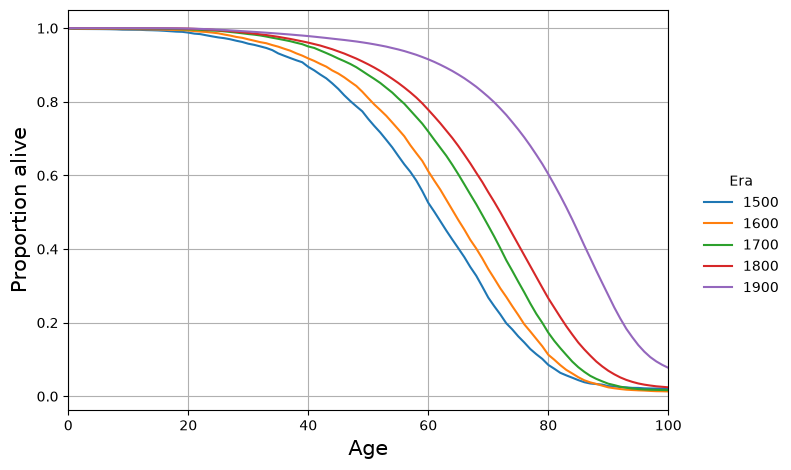

In [ ]:
plt.figure(figsize=(8, 5))
plt.clf()
plt.axes([0.1, 0.1, 0.75, 0.8])
plt.grid(True)
for k,g in dx.groupby("era"):
    sf = sm.SurvfuncRight(g.clifespan, g.died)
    la = "%.0f" % (1500 + k*100)
    plt.plot(sf.surv_times, sf.surv_prob, label=la)
plt.xlim(0, 100)
plt.xlabel("Age", size=15)
plt.ylabel("Proportion alive", size=15)
ha, lb = plt.gca().get_legend_handles_labels()
leg = plt.figlegend(ha, lb, loc="right", title="Era")
leg.draw_frame(False)

We can also estimate the marginal survival function for each gender and for each region.

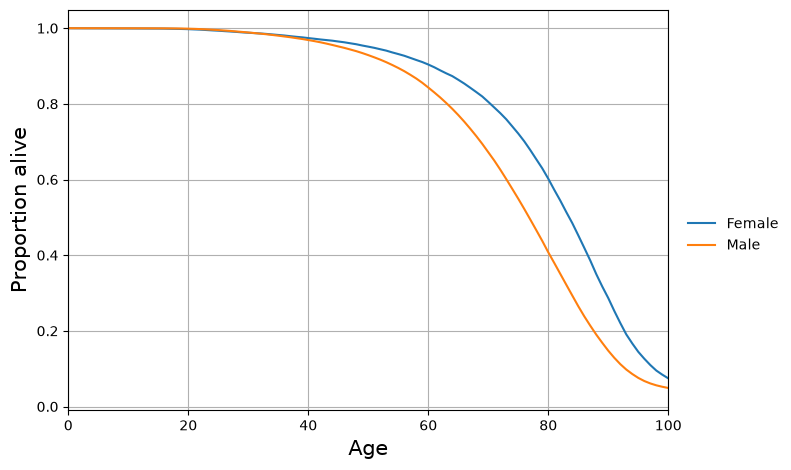

In [ ]:
plt.figure(figsize=(8, 5))
plt.clf()
plt.axes([0.1, 0.1, 0.75, 0.8])
plt.grid(True)
for k,g in dx.groupby("gender"):
    sf = sm.SurvfuncRight(g.clifespan, g.died)
    plt.plot(sf.surv_times, sf.surv_prob, label=k)
plt.xlim(0, 100)
plt.xlabel("Age", size=15)
plt.ylabel("Proportion alive", size=15)
ha, lb = plt.gca().get_legend_handles_labels()
leg = plt.figlegend(ha, lb, loc="right")
leg.draw_frame(False)

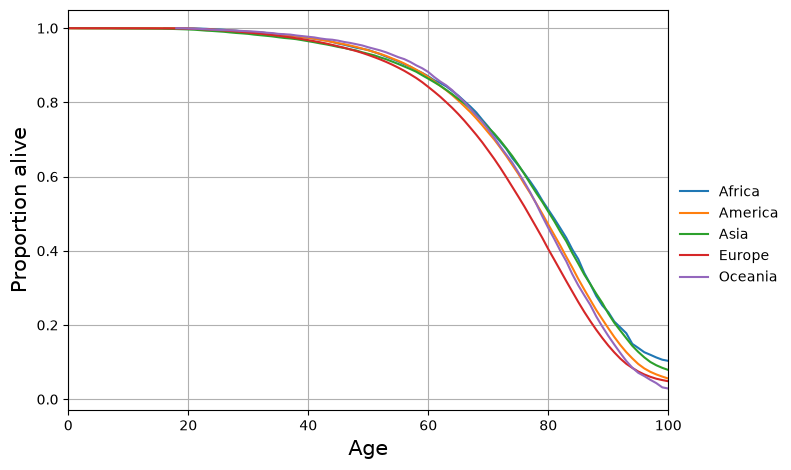

In [ ]:
plt.figure(figsize=(8, 5))
plt.clf()
plt.axes([0.1, 0.1, 0.75, 0.8])
plt.grid(True)
for k,g in dx.groupby("un_region"):
    sf = sm.SurvfuncRight(g.clifespan, g.died)
    plt.plot(sf.surv_times, sf.surv_prob, label=k)
plt.xlim(0, 100)
plt.xlabel("Age", size=15)
plt.ylabel("Proportion alive", size=15)
ha, lb = plt.gca().get_legend_handles_labels()
leg = plt.figlegend(ha, lb, loc="right")
leg.draw_frame(False)

The results above may be heavily influenced by confounding.  The people from Oceania tended to live more recently, and people who lived more recently tend to have longer lifespans.  Conversely, many of the notable people from the 1500's-1700's are from Europe, and lifespans tended to be shorter in these historical eras. Looking at one factor at a time, it is not clear whether the "driver" of lifespan variation is geography (where a person lived) or time (when a person lived).

One possible explanation for increasing lifespans is that early life mortality is reduced.  To assess this, we can estimate the conditional probability of surviving to ages t, given that the person survived to a reference age, which we will set to 60 here.  This focuses the analysis on late rather than early deaths.  This analysis is easy to conduct since the conditional probabilities of interest are simply ratios of the marginal probabilities, e.g. $P(T \ge t | T \ge 60) = P(T \ge t) / P(T \ge 60)$.

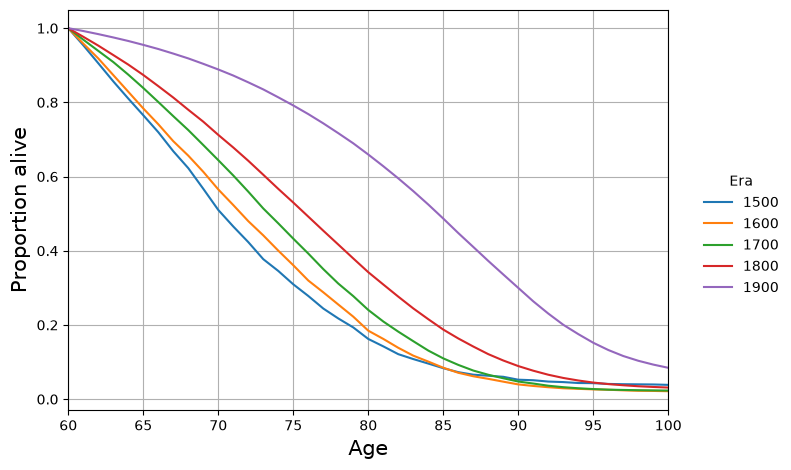

In [ ]:
plt.figure(figsize=(8, 5))
plt.clf()
plt.axes([0.1, 0.1, 0.75, 0.8])
plt.grid(True)
for k,g in dx.groupby("era"):
    sf = sm.SurvfuncRight(g.clifespan, g.died)
    ii = np.flatnonzero(sf.surv_times >= 60)
    la = "%.0f" % (1500 + k*100)
    plt.plot(sf.surv_times[ii], sf.surv_prob[ii]/sf.surv_prob[ii[0]], label=la)
plt.xlim(60, 100)
plt.xlabel("Age", size=15)
plt.ylabel("Proportion alive", size=15)
ha, lb = plt.gca().get_legend_handles_labels()
leg = plt.figlegend(ha, lb, loc="right", title="Era")
leg.draw_frame(False)

## Marginal hazard functions

A very important concept in survival analysis is the hazard function.  This is also known as the "force of mortality", especially in demography and actuarial science.  For the BHHT data, since the times are discrete (ages are in whole years), we can estimate the hazard easily as the ratio of the number of events (deaths) to the number at risk, for each age.  These are plotted below, stratified by era.  It has long been observed that the hazard function is approximately an exponential function of age.  This is known as the [Gompertz-Makeham law of mortality](https://en.wikipedia.org/wiki/Gompertz%E2%80%93Makeham_law_of_mortality).

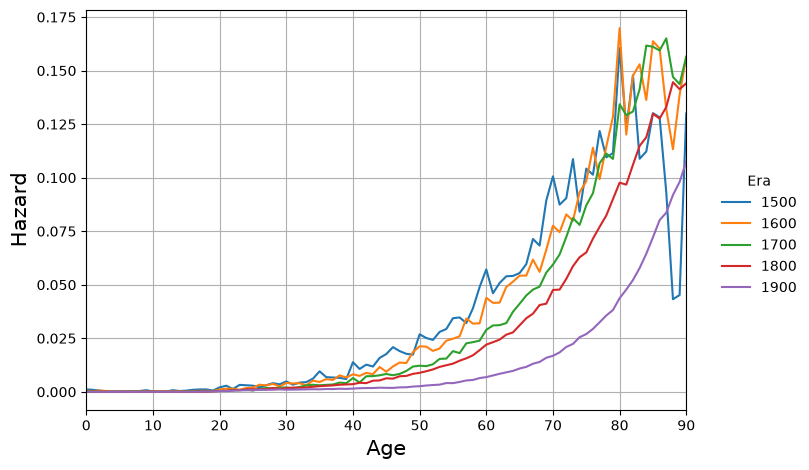

In [ ]:
plt.figure(figsize=(8, 5))
plt.clf()
plt.axes([0.1, 0.1, 0.75, 0.8])
plt.grid(True)
for k,g in dx.groupby("era"):
    sf = sm.SurvfuncRight(g.clifespan, g.died)
    la = "%.0f" % (1500 + k*100)
    plt.plot(sf.surv_times, sf.n_events/sf.n_risk, label=la)
plt.xlabel("Age", size=15)
plt.ylabel("Hazard", size=15)
plt.xlim(0, 90)
ha, lb = plt.gca().get_legend_handles_labels()
leg = plt.figlegend(ha, lb, loc="right", title="Era")
leg.draw_frame(False)

Below we estimate and plot the (marginal) hazard function for each gender.

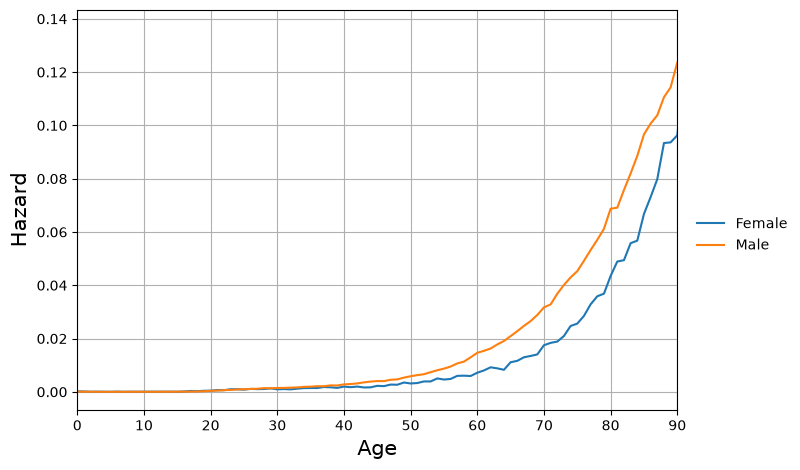

In [ ]:
plt.figure(figsize=(8, 5))
plt.clf()
plt.axes([0.1, 0.1, 0.75, 0.8])
plt.grid(True)
for k,g in dx.groupby("gender"):
    sf = sm.SurvfuncRight(g.clifespan, g.died)
    plt.plot(sf.surv_times, sf.n_events/sf.n_risk, label=k)
plt.xlabel("Age", size=15)
plt.ylabel("Hazard", size=15)
plt.xlim(0, 90)
ha, lb = plt.gca().get_legend_handles_labels()
leg = plt.figlegend(ha, lb, loc="right")
leg.draw_frame(False)

## Proportional hazards modeling


We begin with an additive model that includes main effects for gender and region.  Specifically, this is a log-linear model for the hazard, and is additive in that it includes no interactions.  As seen above with our stratified estimates of the survival function, people from Europe have the shortest lifespans.  Note here that a greater coefficient corresponds to a greater hazard, and hence a shorter lifespan. As always in a regression analysis, the coefficients for categories must be interpreted relative to the omitted reference category.  Note also that unlike many forms of regression, there is no intercept in this model, since an intercept is not identified due to the presence of the baseline hazard function.

In [ ]:
fml = "clifespan ~ gender + un_region"
m0 = sm.PHReg.from_formula(fml, dx, status="died")
r0 = m0.fit()
r0.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Results: PHReg
=========================================================================
Model:                      PH Reg            Sample size:         358075
Dependent variable:         clifespan         Num. events:         226974
Ties:                       Breslow                                      
-------------------------------------------------------------------------
                     log HR log HR SE   HR      t    P>|t|  [0.025 0.975]
-------------------------------------------------------------------------
gender[T.Male]       0.4211    0.0077 1.5237 54.9267 0.0000 1.5010 1.5468
un_region[T.America] 0.1261    0.0225 1.1344  5.6052 0.0000 1.0855 1.1855
un_region[T.Asia]    0.0371    0.0241 1.0378  1.5395 0.1237 0.9899 1.0880
un_region[T.Europe]  0.2710    0.0222 1.3112 12.2260 0.0000 1.2555 1.3694
un_region[T.Oceania] 0.1621    0.0267 1.1760  6.0677 0.0000 1.1160 1.2392
=========================================================================
Confidence intervals are for the hazard ratios
"""

Next we aim to adjust for year, to assess whether the sex and region differences are partly due to confounding with time.  To do this, we create a translated birth year, setting year 1500 as year zero.  This makes it easier to interpret the proportional hazard regression models so that effects are relative to 1500 as a reference year.

In [ ]:
dx["birth1500"] = dx["birth"] - 1500

Below we fit a proportional hazards regression model including main effects for birth year, gender, and region.  In this model, Europe still has the greatest hazard, but its coefficient is now only around 0.02 greater than that for America, whereas in the model that does not adjust for year, Europe's log hazard was around 0.14 greater than that for America. Similarly, the contrast between male and female log hazards drops from 0.42 to 0.30 after controlling for year.

These changes are likely due to similar causes -- the notable people living in earlier years were more likely to be European and male.  Also, in earlier years, lifespans were shorter, since sanitation, agriculture, and medicine were less advanced.  Thus, if we do not adjust for year, it appears that Europeans and males have much shorter lives, but this is partially due to the confounding effect of year.  A small adverse risk for being European remains after adjusting for year, and the risk for being male remains strong after adjusting for year.

In [ ]:
fml = "clifespan ~ birth1500 + gender + un_region"
m1 = sm.PHReg.from_formula(fml, dx, status="died")
r1 = m1.fit()
r1.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                               Results: PHReg
============================================================================
Model:                       PH Reg             Sample size:          358075
Dependent variable:          clifespan          Num. events:          226974
Ties:                        Breslow                                        
----------------------------------------------------------------------------
                      log HR log HR SE   HR       t     P>|t|  [0.025 0.975]
----------------------------------------------------------------------------
gender[T.Male]        0.3019    0.0077 1.3524   39.1798 0.0000 1.3322 1.3730
un_region[T.America]  0.0375    0.0225 1.0382    1.6665 0.0956 0.9934 1.0850
un_region[T.Asia]    -0.0363    0.0241 0.9643   -1.5069 0.1318 0.9198 1.0110
un_region[T.Europe]   0.0585    0.0222 1.0603    2.6356 0.0084 1.0151 1.1074
un_region[T.Oceania]  0.0897    0.0267 1.0939    3.3587 0.0008 1.0381 1.1527
birth1500            -0.0047    0.0000 0.9953 -214.5599 0.0000 0.9952 0.9953
============================================================================
Confidence intervals are for the hazard ratios
"""

If we wish to formally compare the log hazard ratios for Europe and America, we can calculate the contrast between the estimates for these two regions, and the standard error for this contrast.

In [ ]:
d = np.r_[0, -1, 0, 1, 0, 0]
print(np.dot(d, r1.params))
print(np.sqrt(np.dot(d, np.dot(r1.cov_params(), d))))

0.021010366601960234
0.005288880037953024


We use partial regression plots to visualize the fitted model.  The function implemented below plots the partial effect of birth year on the log hazard.

In [ ]:
def plot_birthyear_partial(dx, rr):
    dp = dx.iloc[0:100, :].copy()
    dp["gender"] = "Female"
    # Region is arbitrary but must be fixed
    dp["un_region"] = "Africa"
    dp["birth"] = np.linspace(1500, 1970, 100)
    dp["birth1500"] = dp["birth"] - 1500
    lhr = rr.predict(exog=dp).predicted_values

    plt.clf()
    plt.grid(True)
    plt.plot(dp["birth"].values, lhr)
    plt.xlabel("Birth year", size=15)
    plt.ylabel("Contribution to the log hazard", size=15)

In the second model (m1/r1), there is a linear main effect for birth year.  The hazard of death is decreasing as year of birth increases.

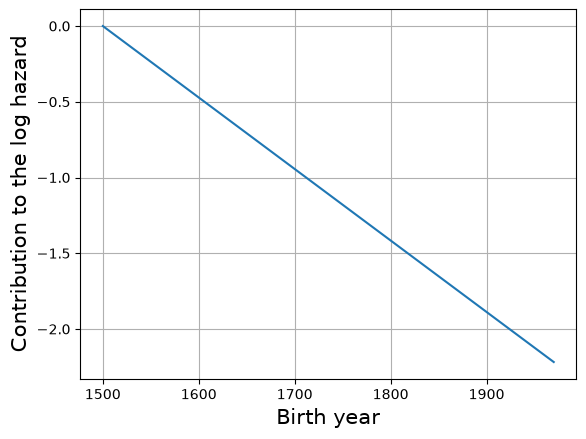

In [ ]:
plot_birthyear_partial(dx, r1)

Next we include a quadratic effect for birth year, to see if the relationship between year of birth and log mortality hazard might be curved (parabolic), holding all other variables fixed. 

In [ ]:
fml = "clifespan ~ birth1500 + I(birth1500**2) + gender + un_region"
m2 = sm.PHReg.from_formula(fml, dx, status="died")
r2 = m2.fit()
r2.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                               Results: PHReg
============================================================================
Model:                       PH Reg             Sample size:          358075
Dependent variable:          clifespan          Num. events:          226974
Ties:                        Breslow                                        
----------------------------------------------------------------------------
                      log HR log HR SE   HR       t     P>|t|  [0.025 0.975]
----------------------------------------------------------------------------
gender[T.Male]        0.2471    0.0077 1.2804   31.9983 0.0000 1.2611 1.2999
un_region[T.America] -0.0760    0.0225 0.9268   -3.3743 0.0007 0.8868 0.9686
un_region[T.Asia]    -0.0395    0.0241 0.9613   -1.6378 0.1015 0.9169 1.0078
un_region[T.Europe]  -0.0574    0.0222 0.9442   -2.5848 0.0097 0.9039 0.9862
un_region[T.Oceania] -0.0262    0.0267 0.9741   -0.9805 0.3268 0.9244 1.0265
birth1500             0.0082    0.0001 1.0082   63.5001 0.0000 1.0080 1.0085
I(birth1500 ** 2)    -0.0000    0.0000 1.0000 -106.4852 0.0000 1.0000 1.0000
============================================================================
Confidence intervals are for the hazard ratios
"""

Since the quadratic term for year of birth is statistically significant, there is evidence for curvature in the relationship between birth year and mortality hazard.  However this model could be mis-specified -- the true relationship might be non-quadratic.

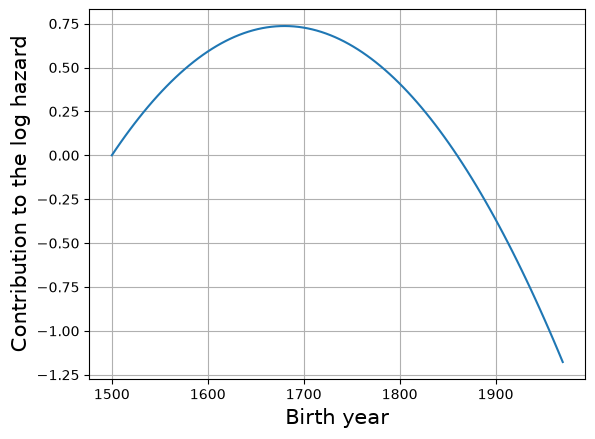

In [ ]:
plot_birthyear_partial(dx, r2)

Next we add a cubic term to the model.

In [ ]:
fml = "clifespan ~ birth1500 + I(birth1500**2) + I(birth1500**3) + gender + un_region"
m3 = sm.PHReg.from_formula(fml, dx, status="died")
r3 = m3.fit()
r3.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                              Results: PHReg
===========================================================================
Model:                        PH Reg            Sample size:         358075
Dependent variable:           clifespan         Num. events:         226974
Ties:                         Breslow                                      
---------------------------------------------------------------------------
                      log HR log HR SE   HR      t     P>|t|  [0.025 0.975]
---------------------------------------------------------------------------
gender[T.Male]        0.2365    0.0077 1.2668  30.6220 0.0000 1.2478 1.2861
un_region[T.America] -0.1247    0.0225 0.8827  -5.5353 0.0000 0.8446 0.9226
un_region[T.Asia]    -0.0663    0.0241 0.9358  -2.7511 0.0059 0.8926 0.9811
un_region[T.Europe]  -0.0984    0.0222 0.9063  -4.4245 0.0000 0.8677 0.9467
un_region[T.Oceania] -0.0896    0.0268 0.9143  -3.3485 0.0008 0.8676 0.9635
birth1500            -0.0129    0.0003 0.9872 -40.5507 0.0000 0.9866 0.9878
I(birth1500 ** 2)     0.0001    0.0000 1.0001  51.0973 0.0000 1.0001 1.0001
I(birth1500 ** 3)    -0.0000    0.0000 1.0000 -67.2431 0.0000 1.0000 1.0000
===========================================================================
Confidence intervals are for the hazard ratios
"""

Based on this model, the mortality hazard was fairly constant until around 1800, then it began to drop.

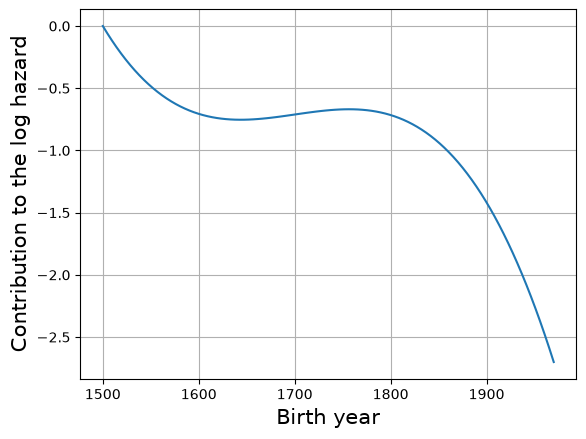

In [ ]:
plot_birthyear_partial(dx, r3)

High order polynomials make poor basis functions.  A more effective approach is polynomial splines, which are piecewise polynomials.  Below we use a cubic spline basis with four degrees of freedom to capture the birth year effect.

In [ ]:
fml = "clifespan ~ bs(birth1500, 4) + gender + un_region"
m4 = sm.PHReg.from_formula(fml, dx, status="died")
r4 = m4.fit()
r4.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                              Results: PHReg
===========================================================================
Model:                        PH Reg            Sample size:         358075
Dependent variable:           clifespan         Num. events:         226974
Ties:                         Breslow                                      
---------------------------------------------------------------------------
                      log HR log HR SE   HR      t     P>|t|  [0.025 0.975]
---------------------------------------------------------------------------
gender[T.Male]        0.2364    0.0077 1.2667  30.6080 0.0000 1.2477 1.2860
un_region[T.America] -0.1249    0.0225 0.8826  -5.5402 0.0000 0.8445 0.9225
un_region[T.Asia]    -0.0665    0.0241 0.9357  -2.7579 0.0058 0.8925 0.9809
un_region[T.Europe]  -0.0985    0.0222 0.9062  -4.4309 0.0000 0.8676 0.9466
un_region[T.Oceania] -0.0897    0.0268 0.9142  -3.3510 0.0008 0.8675 0.9635
bs(birth1500, 4)[0]  -1.7952    0.0468 0.1661 -38.3976 0.0000 0.1515 0.1820
bs(birth1500, 4)[1]   0.7773    0.0219 2.1756  35.4208 0.0000 2.0840 2.2712
bs(birth1500, 4)[2]  -2.2892    0.0245 0.1013 -93.3713 0.0000 0.0966 0.1063
bs(birth1500, 4)[3]  -2.7179    0.0359 0.0660 -75.6552 0.0000 0.0615 0.0708
===========================================================================
Confidence intervals are for the hazard ratios
"""

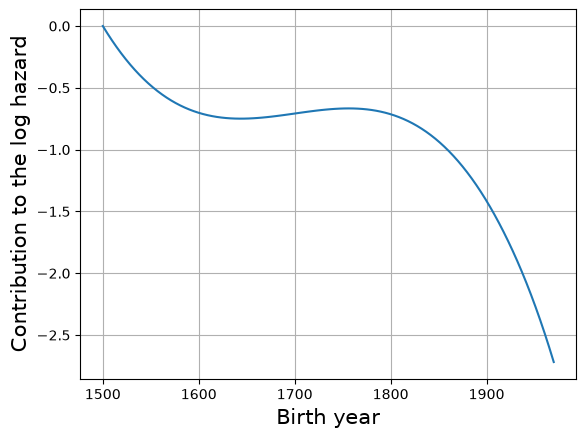

In [ ]:
plot_birthyear_partial(dx, r4)

Above we found that year of birth is a strong predictor of the mortality hazard.  We also have a strong sex difference, with males having a much greater hazard.  Next we consider whether the year of birth effect differs by sex.

In [ ]:
fml = "clifespan ~ bs(birth1500, 4) * gender + un_region"
m5 = sm.PHReg.from_formula(fml, dx, status="died")
r5 = m5.fit()
r5.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                     Results: PHReg
=========================================================================================
Model:                            PH Reg                 Sample size:              358075
Dependent variable:               clifespan              Num. events:              226974
Ties:                             Breslow                                                
-----------------------------------------------------------------------------------------
                                    log HR log HR SE   HR      t     P>|t|  [0.025 0.975]
-----------------------------------------------------------------------------------------
gender[T.Male]                     -0.2657    0.1032 0.7667  -2.5734 0.0101 0.6262 0.9386
un_region[T.America]               -0.1228    0.0225 0.8844  -5.4489 0.0000 0.8462 0.9244
un_region[T.Asia]                  -0.0663    0.0241 0.9358  -2.7507 0.0059 0.8926 0.9811
un_region[T.Europe]                -0.0967    0.0222 0.9079  -4.3486 0.0000 0.8691 0.9483
un_region[T.Oceania]               -0.0869    0.0268 0.9168  -3.2477 0.0012 0.8699 0.9661
bs(birth1500, 4)[0]                -2.1450    0.2110 0.1171 -10.1657 0.0000 0.0774 0.1770
bs(birth1500, 4)[1]                 0.5615    0.0955 1.7533   5.8767 0.0000 1.4539 2.1144
bs(birth1500, 4)[2]                -2.8924    0.1099 0.0554 -26.3232 0.0000 0.0447 0.0688
bs(birth1500, 4)[3]                -3.2637    0.1204 0.0382 -27.1080 0.0000 0.0302 0.0484
bs(birth1500, 4)[0]:gender[T.Male]  0.3775    0.2163 1.4586   1.7449 0.0810 0.9545 2.2289
bs(birth1500, 4)[1]:gender[T.Male]  0.2146    0.0981 1.2394   2.1873 0.0287 1.0226 1.5023
bs(birth1500, 4)[2]:gender[T.Male]  0.6382    0.1127 1.8930   5.6627 0.0000 1.5178 2.3609
bs(birth1500, 4)[3]:gender[T.Male]  0.5918    0.1259 1.8072   4.7021 0.0000 1.4122 2.3128
=========================================================================================
Confidence intervals are for the hazard ratios
"""

To assess whether the birthyear x gender interaction is significant, we can use a log-likelihood ratio test:

In [ ]:
stat = 2*(r5.llf - r4.llf)
dof = len(r5.params) - len(r4.params)
pval = 1 - chi2(dof).cdf(stat)
print("stat=", stat)
print("dof=", dof)
print("pval=", pval)

stat= 143.4963349495083
dof= 4
pval= 0.0


To understand the meaning of the interaction, we plot below the sex-specific contributions of year of birth to the log hazard.

In [ ]:
def plot_birthyear_partial_sexdiff(dx, rr):
    dp = dx.iloc[0:200, :].copy()
    dp["gender"] = np.concatenate((["Female"]*100, ["Male"]*100))
    dp["female"] = np.concatenate((np.ones(100), np.zeros(100)))
    dp["un_region"] = "Africa"
    b = np.linspace(1500, 1970, 100)
    dp["birth"] = np.concatenate((b, b))
    dp["birth1500"] = dp["birth"] - 1500
    lhr = rr.predict(exog=dp).predicted_values

    plt.figure(figsize=(8, 5))
    plt.clf()
    plt.axes([0.1, 0.1, 0.75, 0.8])
    plt.grid(True)
    plt.plot(dp.iloc[0:100, :]["birth"].values, lhr[0:100], label="Female")
    plt.plot(dp.iloc[100:200, :]["birth"].values, lhr[100:200], label="Male")
    ha, lb = plt.gca().get_legend_handles_labels()
    leg = plt.figlegend(ha, lb, loc="center right")
    leg.draw_frame(False)
    plt.xlabel("Birth year", size=15)
    plt.ylabel("Contribtution to the log hazard", size=15)

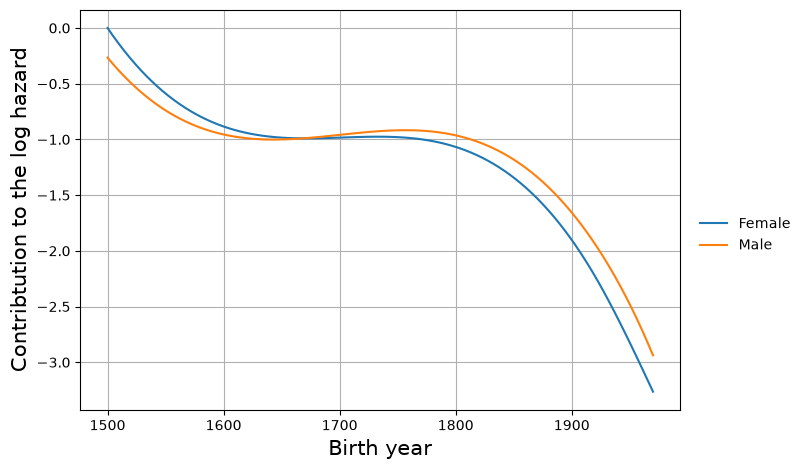

In [ ]:
plot_birthyear_partial_sexdiff(dx, r5)

Above we considered an interaction between a categorical variable (gender) and a quantitative variable (birth1500).  Since the quantitative variable was modeled with splines, this createst an interaction between the gender indicator and each basis function of birth1500.  A more parsimonious way to model interactions involving splines is to model that main effect with a spline, but use only linear terms for the interaction.  This technique is illustrated below.

In [ ]:
dx["female"] = (dx["gender"] == "Female").astype(int)
fml = "clifespan ~ bs(birth1500, 4) + female + birth1500 : female + un_region"
m6 = sm.PHReg.from_formula(fml, dx, status="died")
r6 = m6.fit()
r6.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                              Results: PHReg
===========================================================================
Model:                        PH Reg            Sample size:         358075
Dependent variable:           clifespan         Num. events:         226974
Ties:                         Breslow                                      
---------------------------------------------------------------------------
                      log HR log HR SE   HR      t     P>|t|  [0.025 0.975]
---------------------------------------------------------------------------
un_region[T.America] -0.1228    0.0225 0.8845  -5.4468 0.0000 0.8463 0.9244
un_region[T.Asia]    -0.0664    0.0241 0.9357  -2.7549 0.0059 0.8925 0.9810
un_region[T.Europe]  -0.0966    0.0222 0.9079  -4.3440 0.0000 0.8692 0.9484
un_region[T.Oceania] -0.0870    0.0268 0.9167  -3.2511 0.0011 0.8699 0.9660
bs(birth1500, 4)[0]  -1.7815    0.0468 0.1684 -38.0454 0.0000 0.1536 0.1846
bs(birth1500, 4)[1]   0.7871    0.0220 2.1970  35.7962 0.0000 2.1043 2.2938
bs(birth1500, 4)[2]  -2.2587    0.0247 0.1045 -91.3880 0.0000 0.0995 0.1097
bs(birth1500, 4)[3]  -2.6728    0.0362 0.0691 -73.9321 0.0000 0.0643 0.0741
female                0.2694    0.0421 1.3092   6.3948 0.0000 1.2054 1.4219
birth1500:female     -0.0013    0.0001 0.9987 -12.1259 0.0000 0.9985 0.9989
===========================================================================
Confidence intervals are for the hazard ratios
"""

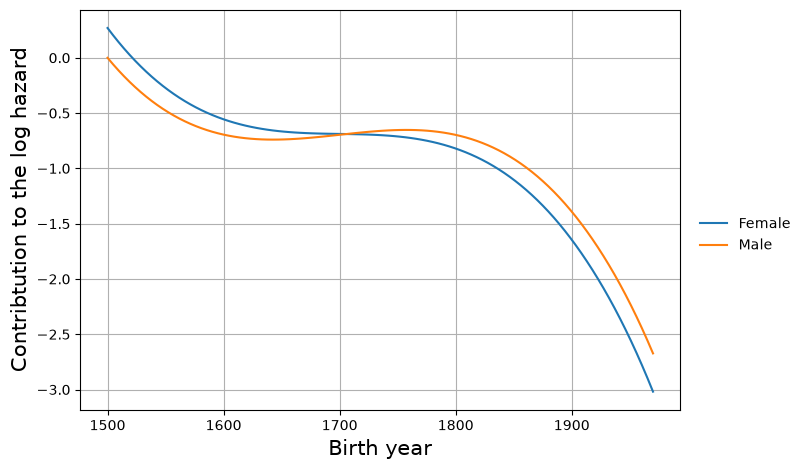

In [ ]:
plot_birthyear_partial_sexdiff(dx, r6)

## Baseline hazard functions

The estimated baseline cumulative hazard function reflects the age-specific hazard of death, controlling for all covariates in the model.  The  cumulative hazard is easy to estimate but not always straightforward to interpret.  For rare events, the cumulative hazard is close to the cumulative risk, in that case, the cumulative hazard will never reach 1, and can be interpreted as being approximately equal to the probability of having the event as of a given time.  However mortality is not rare, therefore the cumulative hazard is not close to the cumulative risk, and as seen in the graph below can substantially exceed 1.  An alternative way to interpret the cumulative hazard that is always valid is based on the fact that the slope of its tangent line is equal to the hazard function.

Text(0, 0.5, 'Cumulative hazard')

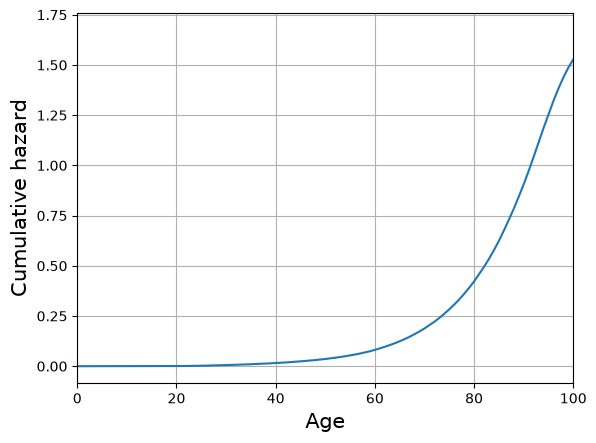

In [ ]:
ti, cumhaz, surv = r0.baseline_cumulative_hazard[0]

plt.clf()
plt.grid(True)
plt.plot(ti, cumhaz)
plt.xlim(0, 100)
plt.xlabel("Age", size=15)
plt.ylabel("Cumulative hazard", size=15)

Estimate and plot the baseline cumulative hazard function on the log scale

Text(0, 0.5, 'Log cumulative hazard')

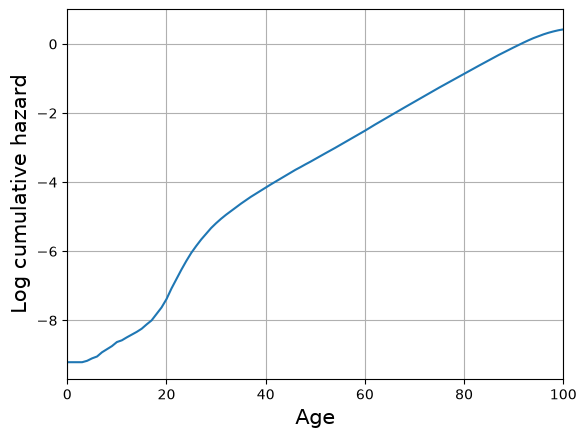

In [ ]:
ti, cumhaz, surv = r0.baseline_cumulative_hazard[0]

plt.clf()
plt.grid(True)
plt.plot(ti, np.log(np.clip(cumhaz, 1e-4, np.inf)))
plt.xlim(0, 100)
plt.xlabel("Age", size=15)
plt.ylabel("Log cumulative hazard", size=15)

Next we estimate and plot the baseline hazard function using numerical differentiation

Text(0, 0.5, 'log hazard')

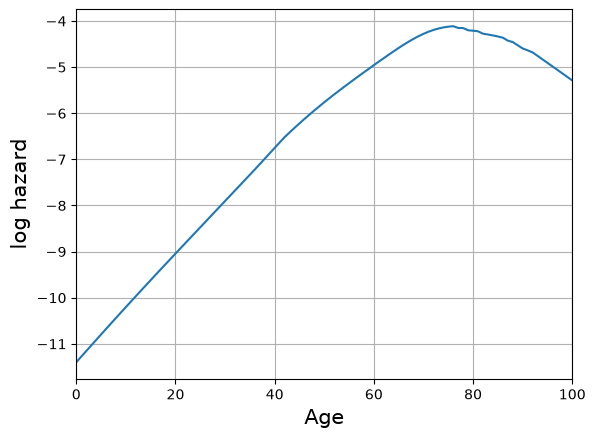

In [ ]:
ti, chaz, surv = r0.baseline_cumulative_hazard[0]
haz = np.diff(chaz) / np.diff(ti)
shaz = sm.nonparametric.lowess(np.log(haz), ti[0:-1])

plt.clf()
plt.grid(True)
plt.plot(shaz[:, 0], shaz[:, 1])
plt.xlim(0, 100)
plt.xlabel("Age", size=15)
plt.ylabel("log hazard", size=15)

# Stratification

In a stratified PH model, each stratum has its own baseline hazard function, but the hazard ratios (determined by the regression coefficients) are the same for all strata.  Below we fit a sex-stratified proportional hazards regression model.  This allows for more complex sex differences compared to including only a sex indicator in the linear predictor.

In [ ]:
fml = "clifespan ~ bs(birth, 4) + un_region"
m7 = sm.PHReg.from_formula(fml, dx, status="died", strata="gender")
r7 = m7.fit()
r7.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                              Results: PHReg
===========================================================================
Model:                     PH Reg          Num strata:             2       
Dependent variable:        clifespan       Min stratum size:       42651   
Ties:                      Breslow         Max stratum size:       315424  
Sample size:               358075          Avg stratum size:       179037.5
Num. events:               226974                                          
---------------------------------------------------------------------------
                      log HR log HR SE   HR      t     P>|t|  [0.025 0.975]
---------------------------------------------------------------------------
un_region[T.America] -0.1258    0.0225 0.8818  -5.5817 0.0000 0.8437 0.9216
un_region[T.Asia]    -0.0679    0.0241 0.9343  -2.8157 0.0049 0.8912 0.9796
un_region[T.Europe]  -0.0995    0.0222 0.9053  -4.4765 0.0000 0.8667 0.9456
un_region[T.Oceania] -0.0906    0.0268 0.9134  -3.3856 0.0007 0.8667 0.9626
bs(birth, 4)[0]      -1.8006    0.0468 0.1652 -38.5006 0.0000 0.1507 0.1811
bs(birth, 4)[1]       0.7687    0.0219 2.1569  35.0200 0.0000 2.0661 2.2517
bs(birth, 4)[2]      -2.2901    0.0245 0.1013 -93.3732 0.0000 0.0965 0.1062
bs(birth, 4)[3]      -2.7328    0.0360 0.0650 -75.9311 0.0000 0.0606 0.0698
===========================================================================
Confidence intervals are for the hazard ratios
"""

Plot the estimated baseline hazard function for each sex:

<Figure size 640x480 with 0 Axes>

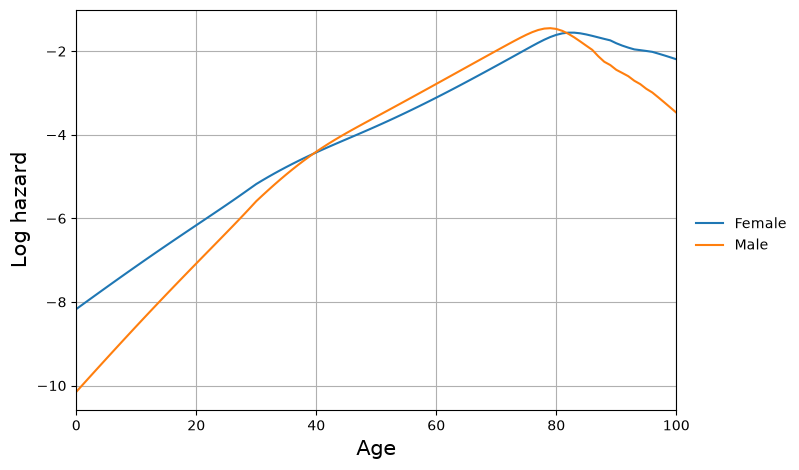

In [ ]:
bh = r7.baseline_cumulative_hazard
snames = m7.surv.stratum_names

plt.clf()
plt.figure(figsize=(8, 5))
plt.axes([0.1, 0.1, 0.75, 0.8])
plt.grid(True)
for k in 0,1:
    ti = bh[k][0]
    chaz = bh[k][1]
    haz = np.diff(chaz) / np.diff(ti)
    shaz = sm.nonparametric.lowess(np.log(haz), ti[0:-1], frac=0.5)
    plt.plot(shaz[:,0], shaz[:,1], label=snames[k])
plt.xlabel("Age", size=15)
plt.ylabel("Log hazard", size=15)
plt.xlim(0, 100)
ha, lb = plt.gca().get_legend_handles_labels()
leg = plt.figlegend(ha, lb, loc="right")
leg.draw_frame(False)

## Additive hazards analysis

Below we use Aalen's additive hazard model to understand how the mortality hazard function differs based on year of birth and sex.

In [ ]:
dx.head()
a = []
for age in range(1, 91):
    dx["y"] = ((dx["clifespan"] == age) & dx["died"]).astype(int)
    ii = dx["clifespan"] >= age
    md = sm.OLS.from_formula("y ~ birth1500 + female", data=dx[ii])
    mr = md.fit()
    a.append(mr.params)

The results plotted below show an approximately exponential increase in cumulative hazards with respect to age.  The contributions to the cumulative hazard of birth year and female sex have a negative sign, indicating lower hazards for people born later in history, and for females.  Neither of these effects seems to be constant in age, since the cumulative coefficients of these variables do not follow a linear pattern.  In particular, the benefits of being female and of being later-born are nearly zero for individuals younger than around 20, and increase with age.

In [ ]:
a = np.vstack(a)
b = a.cumsum(0)
vnames = ["Intercept", "Birth1500", "Female"]
for k in range(3):
    plt.grid(True)
    plt.plot(a[:, k])
    plt.xlabel("Age")
    plt.ylabel("Contribution to cumulative hazard")
    plt.title(vnames[k])
    plt.show()